In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from IPython.display import display

from tqdm import tqdm

import pandas as pd

from scipy import stats

from scipy.ndimage import gaussian_filter

import pyunfold as pu

from scipy.io import loadmat

In [2]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [3]:
site = 'DomeC'
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))

df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

z_samp = Prop.z_samp

In [4]:
# sets the conditions for the study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
Prop_TG = Propagator(pressure=9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
              elev=526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
              rho_ice=0.92) # (g/cm^3) density used in Taylor Glacier analysis
h_bins_TG = np.arange(0, 1001, 1)
Prop_TG.set_mass_depth(z_bins=h_bins_TG/Prop_TG.rho_ice, h_bins=h_bins_TG, z_min=0., z_deep=h_bins_TG[-1]/Prop_TG.rho_ice)
# sample mid depths = [6.85, 10., 15, 19.5, 40.5, 51, 61.5, 72.]
density_model = ('MSIS00', ('SouthPole', 'January'))

df_Pfast_TG = pd.read_csv('Production Rates/P_fast_TaylorGlacier_526m.csv')
df_Pneg_TG = pd.read_csv('Production Rates/P_neg_TaylorGlacier_526m.csv')
P_14C_TG = np.swapaxes([df_Pfast_TG.T, df_Pneg_TG.T], 0, 1)
model_names_TG = list(df_Pfast_TG.columns)

# The only production model being used is Heisinger
i = model_names_TG.index('Heisinger')
prod_cut_TG = np.arange(len(P_14C_TG))[i:i+1]

flow = 'sample'
flowpath = loadmat('matlab/MC_14CO_mod/flowpath_{}.mat'.format(flow))
age = flowpath['age'][0]

Prop_TG.Phi['prod']=P_14C_TG[prod_cut_TG]
C_response_TG, C_init_TG = F.Taylor_flow_response(Prop_TG, flow)

TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')
CO_exp_TG_data = TG_data['CO_molec'][3:,0]
CO_err_TG_data = TG_data['CO_molec_err'][3:,0]/2.
z_samp_TG = TG_data['sample_depth_CO'][3:,0]

In [5]:
# SET TIME-DEPENDENT FLUX MODEL

t_bins = Prop.t_bins[Prop.i_start:]-Prop.t_bins[-1] # time in years, with 0=present
t = Prop.t[Prop.i_start:]-Prop.t_bins[-1]
Period = t_bins[-1]-t_bins[0]
t_scale = t/Period # time scaled from -1 to 0, with 0=present
t_bins_scale = (t_bins/Period).reshape((1,-1))
dt_bins_scale = np.diff(t_bins_scale,axis=-1)

dt_TG = 0.5
t_bins_TG = np.arange(age[0], age[-1]+dt_TG, dt_TG) # time integration steps
t_bins_TG -= t_bins_TG[-1]
t_TG = (t_bins_TG[:-1]+t_bins_TG[1:])/2
t_scale_TG = t_TG/Period
t_bins_scale_TG = (t_bins_TG/Period).reshape((1,-1))
dt_scale_TG = np.diff(t_bins_scale_TG, axis=-1)

N_step = 100

#t_step = np.reshape(np.linspace(-1., 0., N_step+1), (-1,1))
#f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale))/dt_bins_scale
t_step = np.reshape(np.arange(-1.,2./(N_step-1),1./(N_step-1)), (-1,1))
f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

f_step_TG = ((t_step[1:]-t_bins_scale_TG[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale_TG[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

In [6]:
Blur = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/20))**2/2)
Blur /= np.sum(Blur, axis=0, keepdims=True)

Blur_TG = np.exp(-((t_TG.reshape((-1,1))-t_TG.reshape((1,-1)))/(Period/20))**2/2)
Blur_TG /= np.sum(Blur_TG, axis=0, keepdims=True)

In [7]:
C_step = np.swapaxes(f_step @ C_response, -3,-2)
C_step_TG = np.swapaxes(f_step_TG @ C_response_TG, -3,-2)
C_step_all = np.concatenate((C_step, C_step_TG[0]), axis=-1)

In [8]:
f_interp_to_TG = ((t_bins[1:].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG) - (t_bins[:-1].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG))/dt_TG

In [9]:
f_true = np.array([0.08,0.06])
#f_true = np.array([0.,1.])
CO_response = f_true @ np.swapaxes(C_response, -3,-2)
CO_response_TG = f_interp_to_TG @ (f_true @ np.swapaxes(C_response_TG, -3,-2))
CO_init_TG = f_true @ C_init_TG

CO_response_all = np.concatenate((np.expand_dims(CO_response, axis=0),CO_response_TG), axis=-1)

In [10]:
N_f = 21
tf_min, tf_max = np.pi/6, np.pi/3
theta_f = np.linspace(tf_min, tf_max, N_f)
f_unit = np.array([np.cos(theta_f), np.sin(theta_f)]).T
print(theta_f*180/np.pi)

[30.  31.5 33.  34.5 36.  37.5 39.  40.5 42.  43.5 45.  46.5 48.  49.5
 51.  52.5 54.  55.5 57.  58.5 60. ]


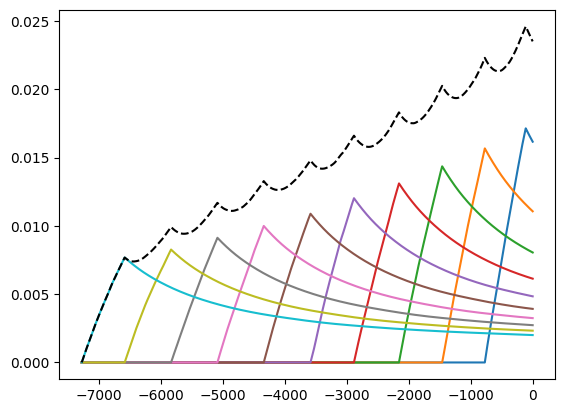

In [11]:
plt.plot(t, CO_response[0])
plt.plot(t, np.sqrt(np.sum(CO_response[0]**2, axis=-1)), c='k', ls='--')
plt.show()

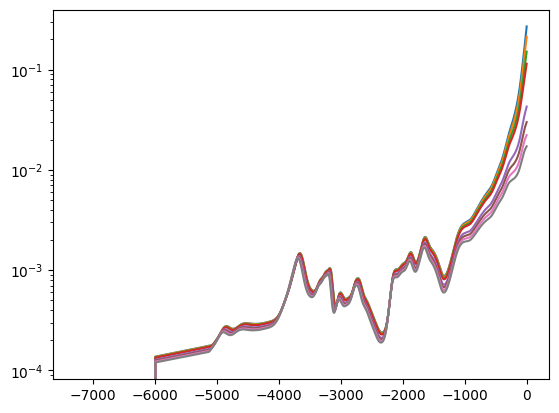

In [12]:
plt.plot(t, CO_response_TG[0,0])
plt.yscale('log')
plt.show()

In [13]:
def get_err(CO_exp, rel_err = 0.02, rel_cov = 0.):
    CO_err = np.abs(CO_exp * rel_err)

    Sigma = CO_err.reshape((*CO_err.shape, 1))*CO_err.reshape((*CO_err.shape[:-1],1,CO_err.shape[-1])) * rel_cov
    Sigma[np.arange(CO_err.shape[-1]),np.arange(CO_err.shape[-1])] = CO_err**2
    Sigma_inv = np.linalg.inv(Sigma)
    
    return CO_err, Sigma, Sigma_inv

In [14]:
CO_base = np.sum(CO_response[0], axis=-2)
CO_base_TG = np.sum(CO_response_TG[0,0], axis=-2)
CO_base_all = np.concatenate((CO_base, CO_base_TG), axis=-1)

rel_err = 0.02
rel_cov = 0. # correlation of experimental errors

rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data)
rel_cov_TG = 0.

CO_base_err, Sigma_base, Sigma_base_inv = get_err(CO_base, rel_err, rel_cov)
CO_base_err_TG, Sigma_base_TG, Sigma_base_inv_TG = get_err(CO_base_TG, rel_err_TG, rel_cov_TG)

CO_base_err_all = np.concatenate((CO_base_err, CO_base_err_TG), axis=-1)

Sigma_base_all = np.zeros((*CO_base_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_base_all[:len(z_samp),:len(z_samp)] = Sigma_base
Sigma_base_all[len(z_samp):,len(z_samp):] = Sigma_base_TG
Sigma_base_inv_all = np.zeros((*CO_base_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_base_inv_all[:len(z_samp),:len(z_samp)] = Sigma_base_inv
Sigma_base_inv_all[len(z_samp):,len(z_samp):] = Sigma_base_inv_TG

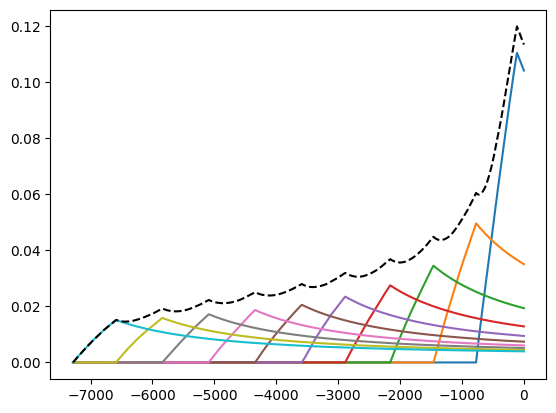

In [15]:
var, vec = np.linalg.eig(Sigma_base)
plt.plot(t, CO_response[0] @ vec / np.sqrt(var).reshape((1,-1)))
plt.plot(t, np.sqrt(np.sum((CO_response[0] @ vec / np.sqrt(var).reshape((1,-1)))**2, axis=-1)), c='k', ls='--')
plt.show()

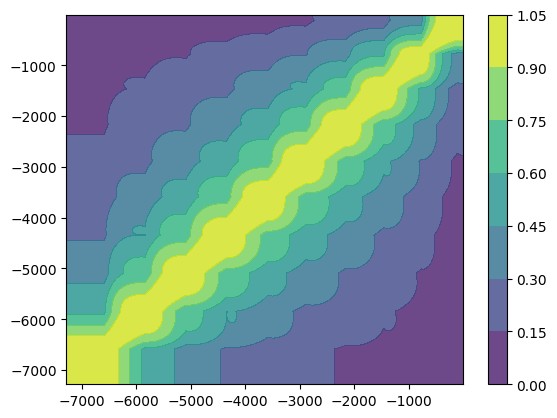

In [16]:
x = CO_response[0] @ vec / np.sqrt(var).reshape((1,-1))
x_mag = np.sqrt(np.sum(x**2, axis=1, keepdims=True))
plt.contourf(t,t, x @ T(x) / (x_mag * T(x_mag)), alpha=0.8)
plt.colorbar()
plt.show()

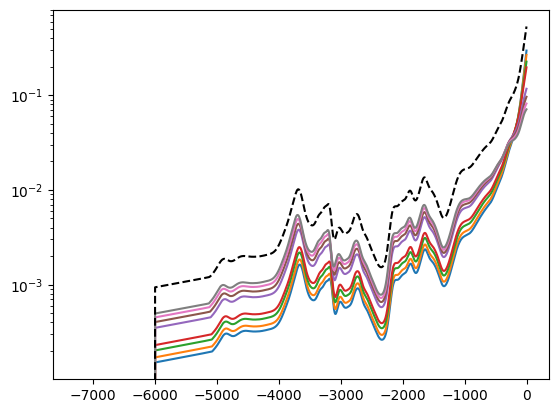

In [17]:
var, vec = np.linalg.eig(Sigma_base_TG)
plt.plot(t, CO_response_TG[0,0] @ vec / np.sqrt(var).reshape((1,-1)))
plt.plot(t, np.sqrt(np.sum((CO_response_TG[0,0] @ vec / np.sqrt(var).reshape((1,-1)))**2, axis=-1)), c='k', ls='--')
plt.yscale('log')
plt.show()

/tmp/ipykernel_596/453843030.py:3: RuntimeWarning: invalid value encountered in divide
  plt.contourf(t,t, x @ T(x) / (x_mag * T(x_mag)), alpha=0.8)


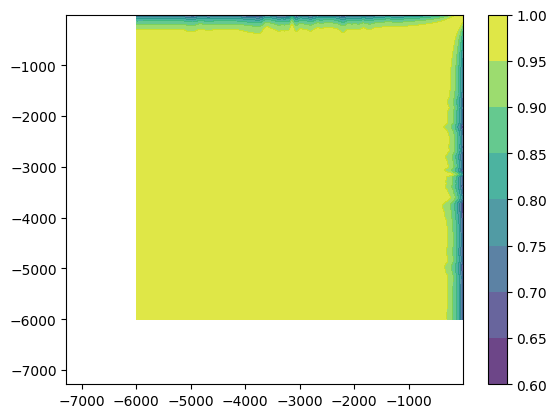

In [18]:
x = CO_response_TG[0,0] @ vec / np.sqrt(var).reshape((1,-1))
x_mag = np.sqrt(np.sum(x**2, axis=1, keepdims=True))
plt.contourf(t,t, x @ T(x) / (x_mag * T(x_mag)), alpha=0.8)
plt.colorbar()
plt.show()

In [19]:
C0 = np.sum(C_response, axis=-2)
C0_TG = (np.sum(C_response_TG, axis=-2) + C_init_TG)
C0_all = np.concatenate((np.expand_dims(C0, axis=0), C0_TG), axis=-1)

F_hat = np.linalg.inv(C0 @ Sigma_base_inv @ T(C0)) @ C0 @ Sigma_base_inv
F_hat_TG = np.linalg.inv(C0_TG @ Sigma_base_inv_TG @ T(C0_TG)) @ C0_TG @ Sigma_base_inv_TG
F_hat_all = np.linalg.inv(C0_all @ Sigma_base_inv_all @ T(C0_all)) @ C0_all @ Sigma_base_inv_all

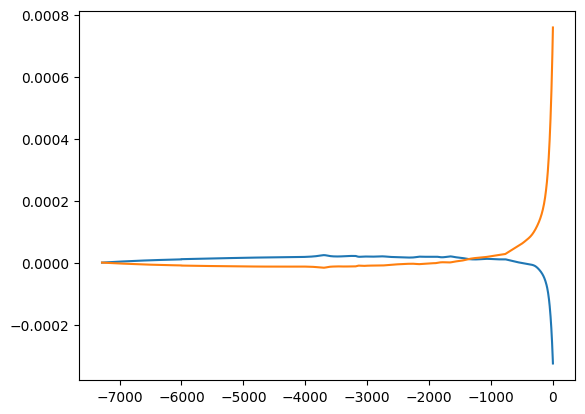

In [20]:
#plt.plot(t, CO_response[0] @ T(F_hat)[0])
#plt.plot(t, CO_response_TG[0,0] @ T(F_hat_TG)[0,0])
plt.plot(t, CO_response_all[0,0] @ T(F_hat_all)[0,0])
plt.show()

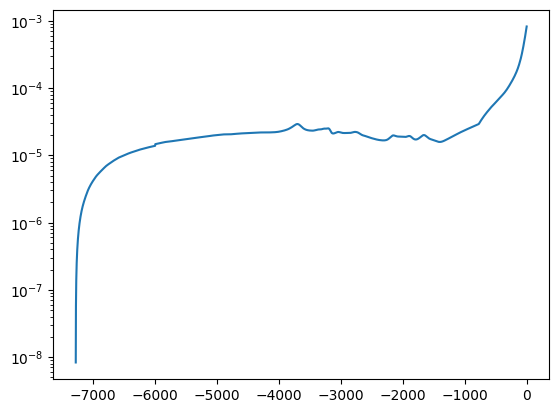

In [21]:
plt.plot(t, np.sqrt(np.sum((CO_response_all[0,0] @ T(F_hat_all)[0,0])**2, axis=-1)))
plt.yscale('log')

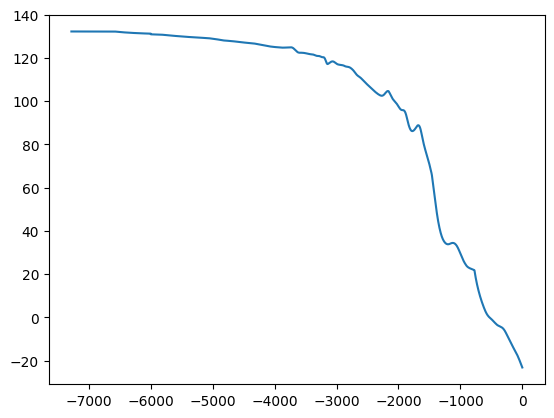

In [22]:
x = CO_response_all[0,0] @ T(F_hat_all)[0,0]
plt.plot(t, np.arctan(x[:,0]/x[:,1])*180/np.pi + 180*(np.arctan(x[:,0]/x[:,1])<-0.5))

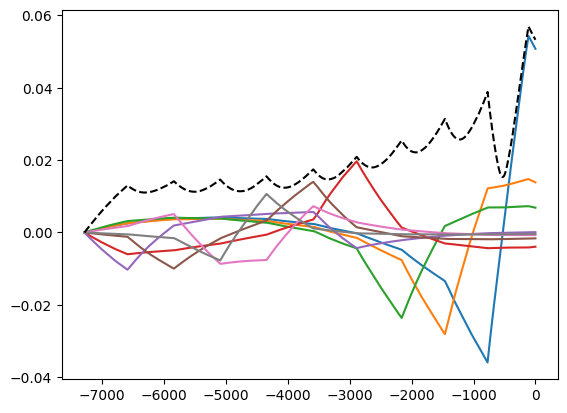

In [23]:
Sigma_fit_inv = T(np.identity(len(z_samp)) - T(C0)[0] @ F_hat[0]) @ Sigma_base_inv @ (np.identity(len(z_samp)) - T(C0)[0] @ F_hat[0])
val, vec = np.linalg.eig(Sigma_fit_inv)
val = 1/val[:-2]
vec = vec[:,:-2]

plt.plot(t, CO_response[0] @ vec / np.sqrt(val).reshape((1,-1)))
plt.plot(t, np.sqrt(np.sum((CO_response[0] @ vec / np.sqrt(val).reshape((1,-1)))**2, axis=-1)), c='k', ls='--')
plt.show()

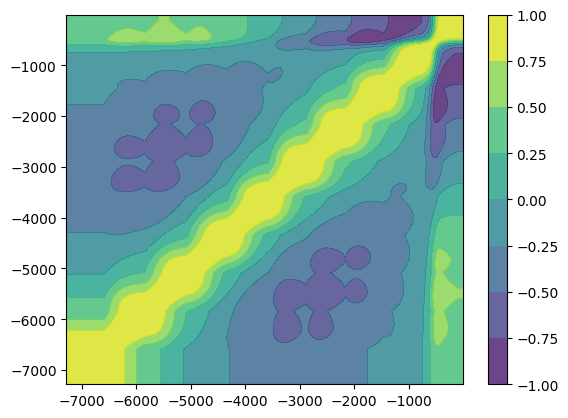

In [24]:
x = CO_response[0] @ vec / np.sqrt(val).reshape((1,-1))
x_mag = np.sqrt(np.sum(x**2, axis=1, keepdims=True))
plt.contourf(t,t, x @ T(x) / (x_mag * T(x_mag)), alpha=0.8)
plt.colorbar()
plt.show()

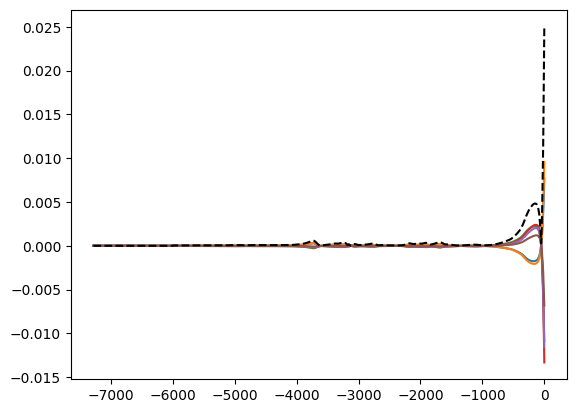

In [25]:
Sigma_fit_inv_TG = T(np.identity(len(z_samp_TG)) - T(C0_TG)[0,0] @ F_hat_TG[0,0]) @ Sigma_base_inv_TG @ (np.identity(len(z_samp_TG)) - T(C0_TG)[0,0] @ F_hat_TG[0,0])
val, vec = np.linalg.eig(Sigma_fit_inv_TG)
val = 1/val[:-2]
vec = vec[:,:-2]

plt.plot(t, CO_response_TG[0,0] @ vec / np.sqrt(val).reshape((1,-1)))
plt.plot(t, np.sqrt(np.sum((CO_response_TG[0,0] @ vec / np.sqrt(val).reshape((1,-1)))**2, axis=-1)), c='k', ls='--')
plt.show()

/tmp/ipykernel_596/515253395.py:3: RuntimeWarning: invalid value encountered in divide
  plt.contourf(t,t, x @ T(x) / (x_mag * T(x_mag)), alpha=0.8)


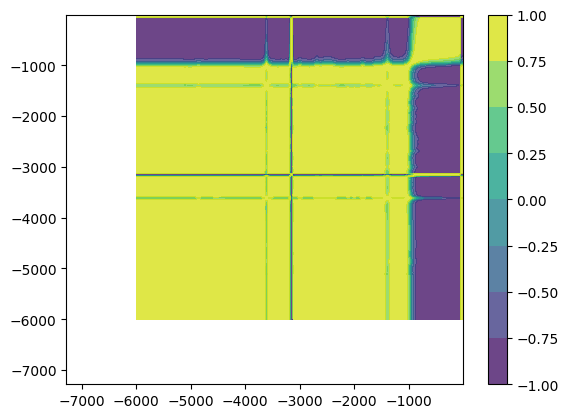

In [26]:
x = CO_response_TG[0,0] @ vec / np.sqrt(val).reshape((1,-1))
x_mag = np.sqrt(np.sum(x**2, axis=1, keepdims=True))
plt.contourf(t,t, x @ T(x) / (x_mag * T(x_mag)), alpha=0.8)
plt.colorbar()
plt.show()

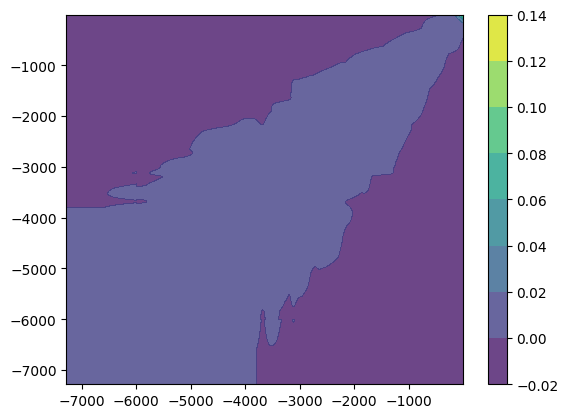

In [32]:
x = CO_response_all[0,0] @ vec / np.sqrt(val).reshape((1,-1))
x_mag = np.sqrt(np.sum(x**2, axis=1, keepdims=True))
plt.contourf(t,t, x @ T(x), alpha=0.8)
plt.colorbar()
plt.show()

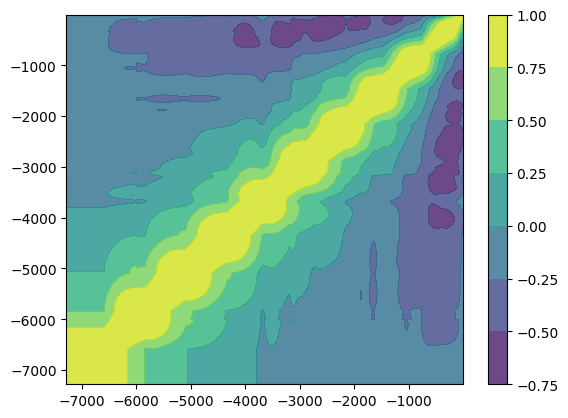

In [29]:
Sig_iv = CO_response_all[0,0] @ Sigma_fit_inv_all @ T(CO_response_all[0,0])
sig_mag = np.sqrt(np.diag(Sig_iv).reshape((-1,1)))
plt.contourf(t,t, Sig_iv / (sig_mag * T(sig_mag)), alpha=0.8)
plt.colorbar()
plt.show()

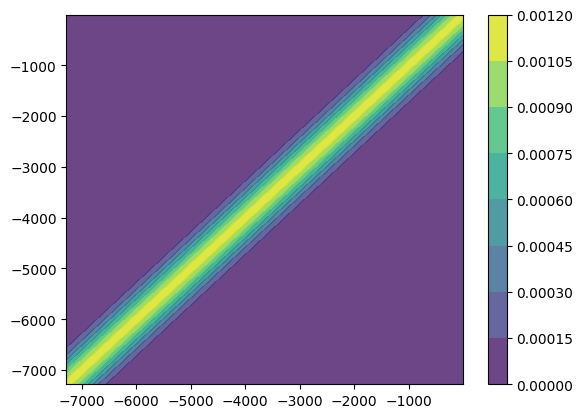

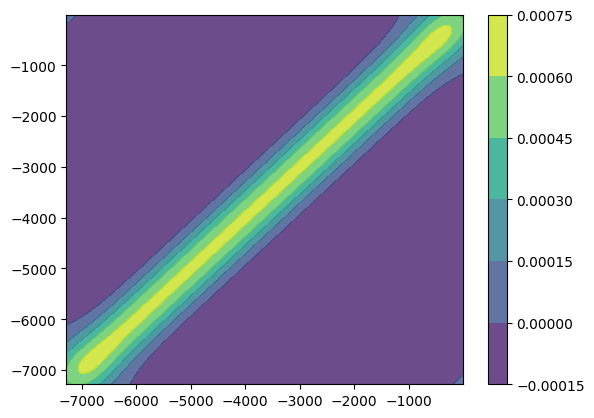

In [113]:
D = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/20))**2/2) / np.sqrt(2*np.pi) / (Period/20)
#D /= np.sum(D, axis=0, keepdims=True)

plt.contourf(t,t, D, alpha=0.8)
plt.colorbar()
plt.show()

#plt.contourf(t,t, Sig_iv / (sig_mag * T(sig_mag)), alpha=0.8)
plt.contourf(t,t, T(np.identity(len(t)) - 1/Period) @ T(D) @ D @ (np.identity(len(t)) - 1/Period), alpha=0.8)
plt.colorbar()
plt.show()

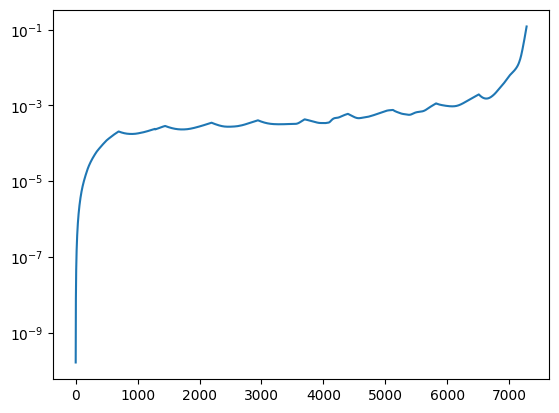

In [35]:
plt.plot(np.diag(Sig_iv))
plt.yscale('log')

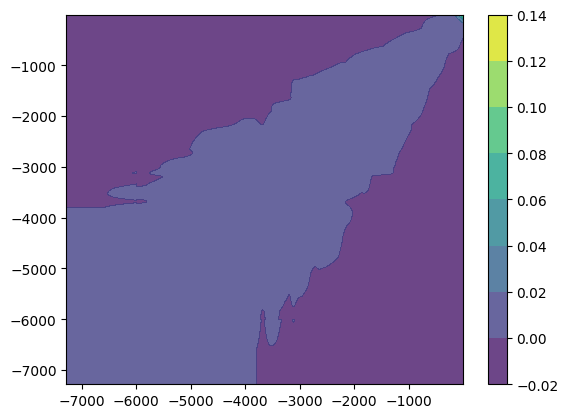

In [61]:
plt.contourf(t, t, x @ x.T, alpha=0.8)
plt.colorbar()
plt.show()

In [62]:
x_sort = x[:,np.argsort(np.sum(-x**2, axis=0))]

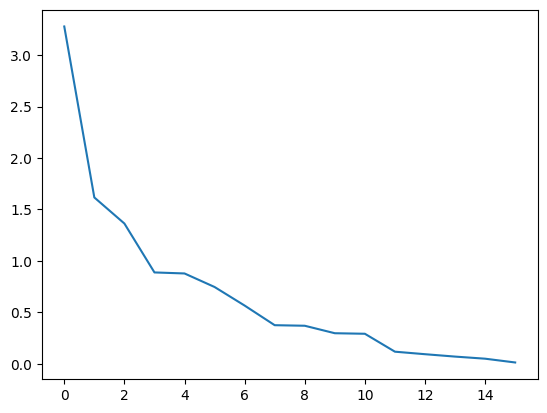

In [75]:
plt.plot(np.sum(x_sort**2, axis=0))

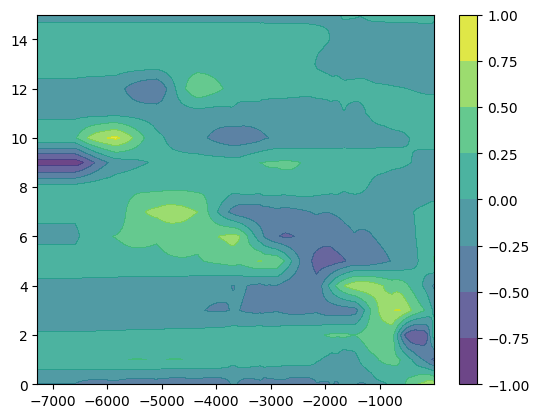

In [93]:
plt.contourf(t, np.arange(16), x_sort.T/x_mag.T, alpha=0.8)
plt.colorbar()
plt.show()

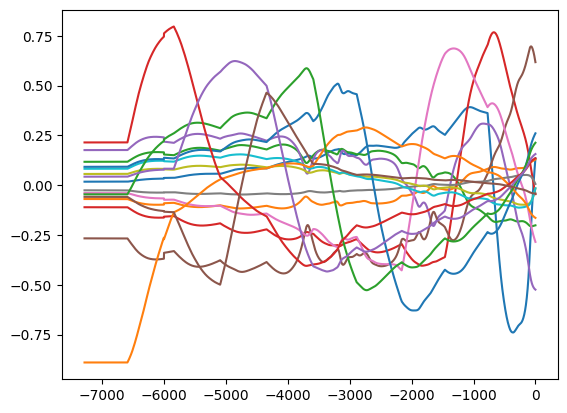

In [27]:
Sigma_fit_inv_all = T(np.identity(len(z_samp) + len(z_samp_TG)) - T(C0_all)[0,0] @ F_hat_all[0,0]) @ Sigma_base_inv_all @ (np.identity(len(z_samp) + len(z_samp_TG)) - T(C0_all)[0,0] @ F_hat_all[0,0])
val, vec = np.linalg.eig(Sigma_fit_inv_all)
val = 1/val[:-2]
vec = vec[:,:-2]

mag = np.sqrt(np.sum((CO_response_all[0,0] @ vec / np.sqrt(val).reshape((1,-1)))**2, axis=-1))
plt.plot(t, CO_response_all[0,0] @ vec / np.sqrt(val).reshape((1,-1)) / mag.reshape((-1,1)))
#plt.plot(t, mag, c='k', ls='--')
plt.show()

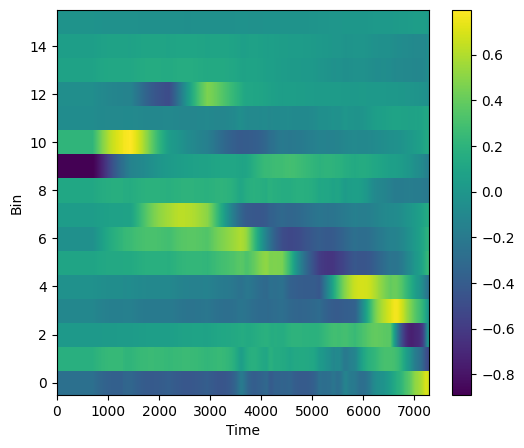

In [96]:
fig, ax = plt.subplots(1,1,figsize=(6,5))
im = ax.imshow(x_sort.T/x_mag.T, origin='lower', aspect='auto', interpolation='none')
cbar = plt.colorbar(im)
ax.set(xlabel='Time',
       ylabel='Bin',
)
#ax.set_xticks(t,labels=t)
#ax.set_yticks(np.arange(len(Y)),labels=Y)
#plt.title('French Starting Phoneme Frequency')
plt.show()

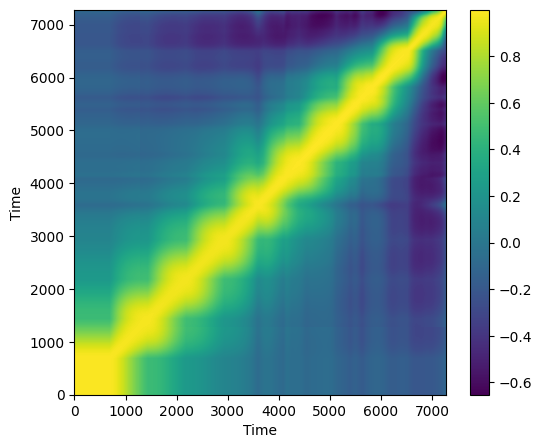

In [116]:
i=13
fig, ax = plt.subplots(1,1,figsize=(6,5))
im = ax.imshow(x_sort[:,:i] @ x_sort[:,:i].T /(x_mag * T(x_mag)), origin='lower', aspect='auto', interpolation='none')
cbar = plt.colorbar(im)
ax.set(xlabel='Time',
       ylabel='Time',
)
plt.show()

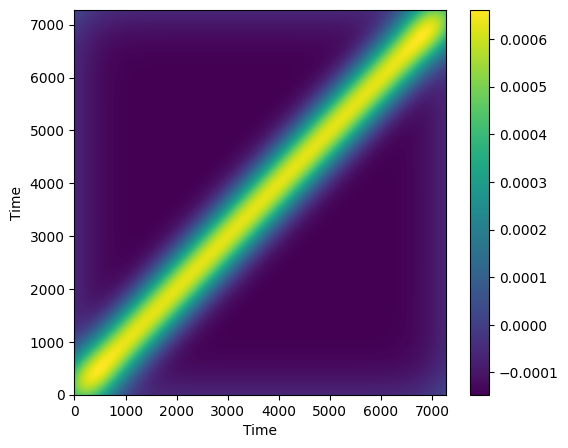

In [111]:
fig, ax = plt.subplots(1,1,figsize=(6,5))
im = ax.imshow(T(np.identity(len(t)) - 1/Period) @ T(D) @ D @ (np.identity(len(t)) - 1/Period), origin='lower', aspect='auto', interpolation='none')
cbar = plt.colorbar(im)
ax.set(xlabel='Time',
       ylabel='Time',
)
plt.show()

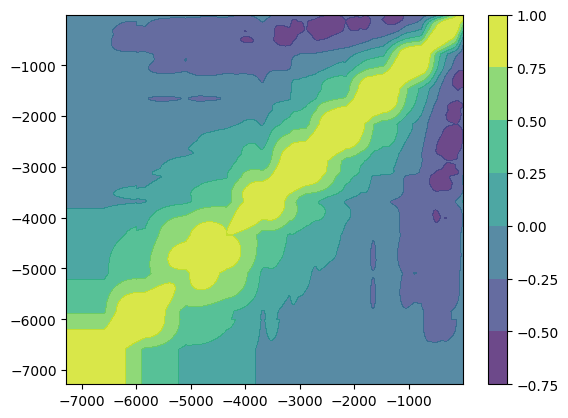

In [89]:
i = 11
plt.contourf(t, t, x_sort[:,:i] @ x_sort[:,:i].T /(x_mag * T(x_mag)), alpha=0.8)
plt.colorbar()
plt.show()

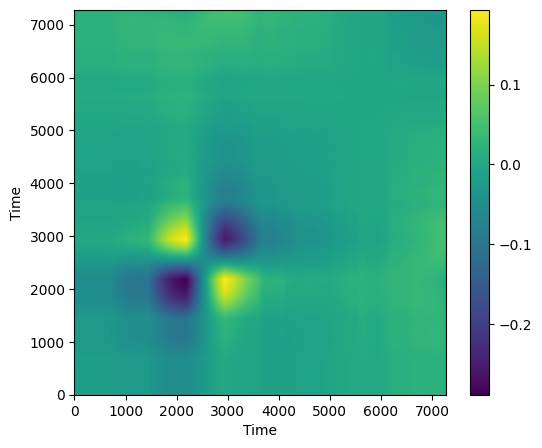

In [101]:
i=11
fig, ax = plt.subplots(1,1,figsize=(6,5))
im = ax.imshow(((x_sort[:,:i] @ x_sort[:,:i].T - (x_sort @ x_sort.T))/(x_mag * x_mag.T)), origin='lower', aspect='auto', interpolation='none')
cbar = plt.colorbar(im)
ax.set(xlabel='Time',
       ylabel='Time',
)
plt.show()

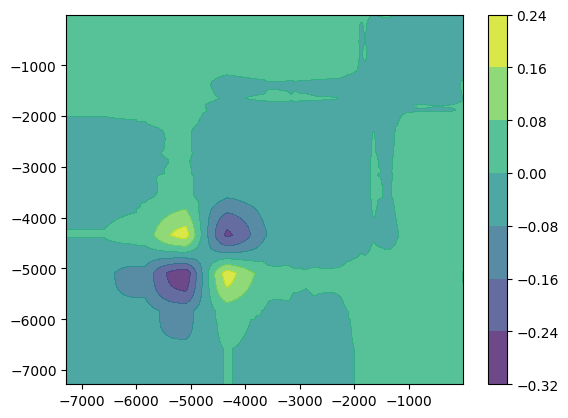

In [88]:
i=11
plt.contourf(t, t, ((x_sort[:,:i] @ x_sort[:,:i].T - (x_sort @ x_sort.T))/(x_mag * x_mag.T)), alpha=0.8)
plt.colorbar()
plt.show()

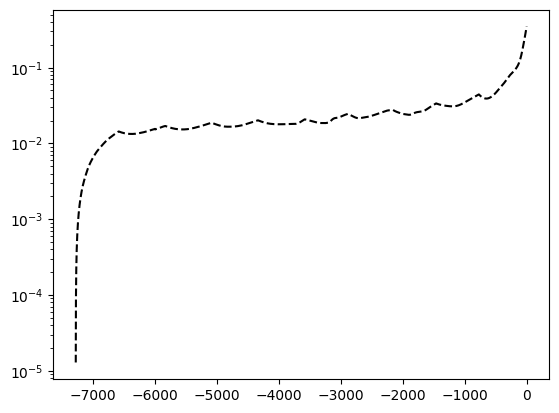

In [31]:
plt.plot(t, np.sqrt(np.sum((CO_response_all[0,0] @ vec / np.sqrt(val).reshape((1,-1)))**2, axis=-1)), c='k', ls='--')
plt.yscale('log')